In [ ]:
import logging
import os
import pickle
import random
import sys
from os.path import join

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xgboost as xgb
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import KFold

sys.path.append("./additional_code")
# from data_preprocessing import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)
our_data = CURRENT_DIR + "/../data/our_data/"

/home/hanxd/Repositories/ESP/our_codes


In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
anotherdata = pd.read_csv(our_data + "cross_score.txt", sep="\t", header=0)
anotherdata["if_right"] = anotherdata["if_right"].replace({1: 0, 2: 1})
ourdata = pd.read_pickle(join(CURRENT_DIR, "..", "data", "our_data", "5foldsdata.pkl"))

In [ ]:
merged_df = pd.merge(
    anotherdata,
    ourdata,
    left_on=["complex", "name"],
    right_on=["enzyme", "substrate"],
    how="inner",
)
merged_df = merged_df[(merged_df["Binding"] == merged_df["if_right"])]
merged_df = merged_df.sort_values(by="substrate")

In [ ]:
for i in range(0, 101):
    merged_df["scores" + str(i)] = (
        merged_df["wei_score"] * i / 100 + merged_df["scores"] * (100 - i) / 100
    )
    merged_df = merged_df.sort_values(
        by=["substrate", "scores" + str(i)], ascending=[True, False]
    )
    merged_df["ranking" + str(i)] = merged_df.groupby("substrate").cumcount() + 1

In [ ]:
ratios_list = []
substrate_counts = merged_df.groupby("substrate")["substrate"].count()
substrate_counts = 294
for i in range(0, 101):
    binding_1_values = (
        merged_df[merged_df["Binding"] == 1]
        .groupby("substrate")["ranking" + str(i)]
        .mean()
    )
    ranking_ratios = binding_1_values / substrate_counts
    average_ratio = ranking_ratios.median()
    ratios_list.append([i, average_ratio])
ratios_df = pd.DataFrame(ratios_list, columns=["i", "median"])

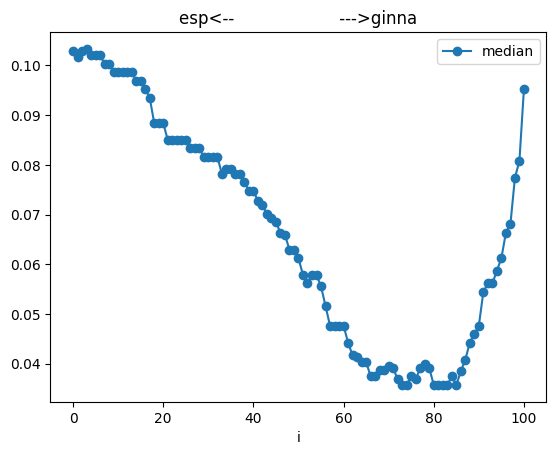

In [ ]:
ratios_df.plot(
    x="i",
    y="median",
    kind="line",
    title="esp<--                    --->ginna",
    marker="o",
)

plt.show()

In [ ]:
ratios_df.sort_values(by="median", ascending=True)

,i,median
82,82,0.035714
80,80,0.035714
81,81,0.035714
73,73,0.035714
74,74,0.035714
...,...,...
5,5,0.102041
4,4,0.102041
2,2,0.102891
0,0,0.102891


In [ ]:
ratios_df[ratios_df["i"] == 100]

,i,median
100,100,0.095238


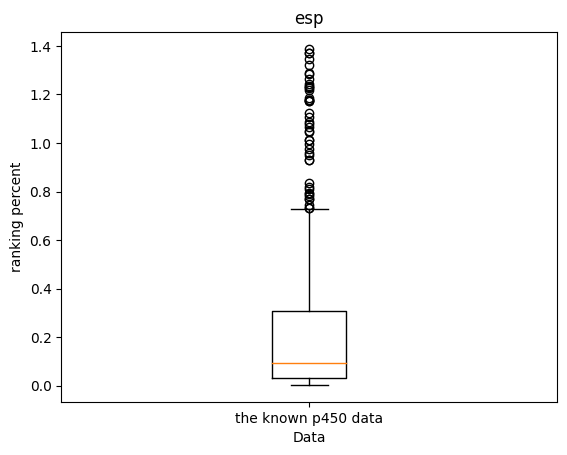

0.09183673469387756


In [ ]:
ourdata_N = ourdata.sort_values(by=["substrate", "scores"], ascending=[True, False])
ourdata_N["ranking"] = ourdata_N.groupby("substrate").cumcount() + 1

df1ranking3 = ourdata_N[ourdata_N["Binding"] == 1]["ranking"] / 294

plt.boxplot(df1ranking3)
plt.title("esp")
plt.xlabel("Data")
plt.ylabel("ranking percent")
plt.xticks([1], ["the known p450 data"])
plt.show()
print(df1ranking3.median())

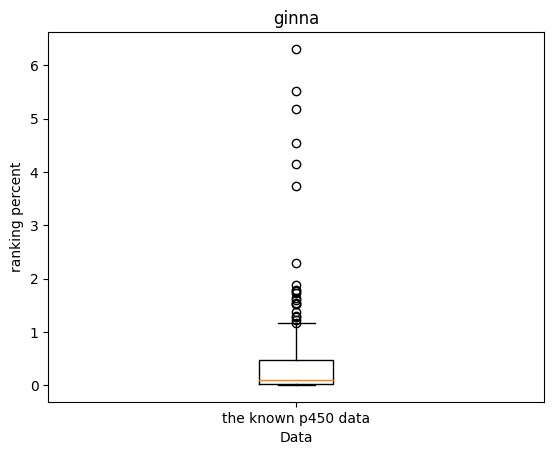

0.09183673469387756


In [ ]:
anotherdata_n = anotherdata.sort_values(
    by=["name", "wei_score"], ascending=[True, False]
)
anotherdata_n["ranking"] = anotherdata_n.groupby("name").cumcount() + 1

df1ranking2 = anotherdata_n[anotherdata_n["if_right"] == 1]["ranking"] / 294
plt.boxplot(df1ranking2)
plt.title("ginna")
plt.xlabel("Data")
plt.ylabel("ranking percent")
plt.xticks([1], ["the known p450 data"])
plt.show()
print(df1ranking2.median())

In [ ]:
anotherdata_n["ranking"].max()

2132

In [ ]:
ourdata_N["ranking"].max()

408